# Understanding Cancellation Behavior
## An Unsupervised Approach to User Segmentation in Ride-Hailing

*KMeans clustering on synthesized ride-hailing data*

---

Every day, drivers on our platform get assigned a trip, drive toward a pickup point, and watch the order disappear. Sometimes it's legitimate. But sometimes it's a pattern — the same user, the same behavior, repeatedly, costing drivers real fuel and lost earnings.

Self-reported cancellation reasons don't help. "Driver too far" can mean anything from a genuine concern to someone gaming the cancel-reorder loop to fish for a better price. What users *say* doesn't tell us much. What they *do* — how quickly they cancel, whether the driver had already arrived, whether they immediately reorder — that's the actual signal.

This notebook builds a behavioral segmentation of users based on 90 days of order history using unsupervised clustering. The output is a risk tier for every active user on the platform, refreshed weekly. No labels, no ground truth, just behavior.


In [1]:
import importlib, subprocess, sys

# All of these ship with Colab; this cell is a safety net for other environments
required = ['pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn']
for pkg in required:
    mod = pkg.replace('-', '_')
    if importlib.util.find_spec(mod) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('All dependencies available.')


All dependencies available.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'figure.figsize': (14, 5),
})

print('Imports done.')


Imports done.


In [3]:
# ── sizing ──────────────────────────────────────────────────────────────────
N_ORDERS      = 2_000_000
N_USERS       = 300_000
N_DRIVERS     = 50_000
N_GEOHASH     = 200
N_CITIES      = 5
LOOKBACK_DAYS = 90
TREND_RECENT  = 30      # days for "recent" window in trend feature

# ── archetype fractions (must sum to 1.0) ───────────────────────────────────
FRAC_GOOD        = 0.65
FRAC_CASUAL      = 0.12
FRAC_SERIAL      = 0.10
FRAC_BAITER      = 0.06
FRAC_FARE_HUNTER = 0.05
FRAC_COLLUDER    = 0.02

ARCHETYPE_NAMES = ['good', 'casual', 'serial', 'baiter', 'fare_hunter', 'colluder']
ARCHETYPE_FRACS = [FRAC_GOOD, FRAC_CASUAL, FRAC_SERIAL, FRAC_BAITER, FRAC_FARE_HUNTER, FRAC_COLLUDER]

# ── modeling ─────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
N_CLUSTERS   = 6
BATCH_SIZE   = 50_000

# ── fare range (IDR) ─────────────────────────────────────────────────────────
FARE_MIN = 15_000
FARE_MAX = 150_000

# ── peak hours (inclusive) ───────────────────────────────────────────────────
PEAK_MORNING = (7, 9)
PEAK_EVENING = (17, 20)

# reference epoch: 2025-01-01 00:00:00 UTC (seconds since Unix epoch)
REF_EPOCH    = 1_735_689_600
WINDOW_SECS  = 180 * 86_400   # 6-month window

# ── colors: one per archetype, used consistently throughout ─────────────────
ARCHETYPE_COLORS = {
    'Good Users':              '#4C72B0',
    'Casual / Inactives':      '#DD8452',
    'Serial Quick Cancelers':  '#C44E52',
    'Baiters':                 '#8172B2',
    'Fare Hunters':            '#55A868',
    'Suspected Colluders':     '#937860',
}

FEATURE_COLS = [
    'cancel_rate', 'avg_seconds_to_cancel', 'baiter_ratio',
    'serial_cancel_flag_rate', 'reorder_after_cancel_rate',
    'peak_hour_cancel_rate', 'cancel_rate_trend',
    'booking_hour_stddev', 'pickup_diversity_ratio',
    'top_driver_concentration',
    'promo_usage_rate', 'avg_promo_depth', 'net_contribution_per_order',
]

print('Constants set.')


Constants set.


---
## 1. Business Problem & Framing


### Why cancellations are a bigger deal than they look

When a user cancels, it's not just a lost trip. The driver spent fuel and time driving to the pickup point. They missed other ride requests during that window. If it happens repeatedly — especially if the driver arrived before the cancel — it erodes driver confidence in the platform and inflates effective driver idle time.

At scale, the economics are real: a driver doing 8 trips per day who encounters 2 post-arrival cancels has lost roughly 25% of their productive time to users gaming the system. Multiply that across 50,000 active drivers and the impact on earnings (and driver retention) becomes a board-level concern.

**What makes this hard to fix with rules:**

The obvious approach — flag users with high cancel rates — doesn't work well. A user with 3 cancels out of 4 orders looks terrible. A user with 30 cancels out of 300 orders is completely normal. Cancel rate alone is noisy, especially for users with few trips.

Self-reported reason codes make it worse. "Driver too far" is the most popular cancel reason, but it's used by serial quick-cancelers (who click it 8 seconds after assignment), baiters (who waited 10 minutes and then cancelled after the driver arrived), and genuinely frustrated users (whose driver was assigned 15km away). Same label, completely different behavior.

**The analytical objective:**

Segment users by *actual behavioral pattern* — timing, consistency, promo dependency, driver targeting — using 90 days of order history. The output is a cluster assignment per user that maps to a risk tier. No ground truth labels needed. The clusters should be interpretable, stable over time, and actionable.

**Six behavioral archetypes we expect to find:**

| Archetype | Key behavioral signal | Business risk |
|---|---|---|
| Good Users | Low cancel rate, varied timing, low promo dependency | None |
| Casual / Inactives | Few orders, moderate cancel rate by small sample size | Minimal |
| Serial Quick Cancelers | Cancel within 30s of assignment, high volume | Moderate — driver time waste |
| Baiters | Cancel after driver arrived, spike during peak hours | High — direct driver earnings loss |
| Fare Hunters | Cancel + reorder within 10 min, promo-heavy | High — promo abuse, platform trust |
| Suspected Colluders | High repeat-driver concentration, unusual patterns | Critical — potential fraud |

These aren't guaranteed to emerge cleanly — real user behavior is messy. But they give us a framework to evaluate whatever clusters we find.


---
## 2. Data Synthesis & Exploration


The dataset is synthesized here rather than loaded from a real source. I'm generating it with known behavioral archetypes baked into the distribution — but adding noise to every parameter, so the clusters don't separate perfectly. If the data were clean enough that you could just eyeball it, you wouldn't need clustering.

### Users table


In [4]:
import time
t_start = time.time()

rng = np.random.default_rng(RANDOM_STATE)

user_ids   = np.arange(N_USERS)
archetypes = rng.choice(ARCHETYPE_NAMES, size=N_USERS, p=ARCHETYPE_FRACS)

# 5 cities, one dominant market (~Jakarta-equivalent at 40%)
city_names  = ['Jakarta', 'Surabaya', 'Bandung', 'Medan', 'Makassar']
city_probs  = [0.40, 0.20, 0.17, 0.13, 0.10]
cities      = rng.choice(city_names, size=N_USERS, p=city_probs)

# Mix of new accounts (<30 days) and tenured (up to 3 years)
is_new        = rng.random(N_USERS) < 0.15
account_days  = np.where(is_new,
                         rng.integers(1, 30, N_USERS),
                         rng.integers(30, 1095, N_USERS))
account_ts    = pd.to_datetime(REF_EPOCH - account_days * 86_400, unit='s')

users_df = pd.DataFrame({
    'user_id':            user_ids,
    'archetype':          archetypes,
    'city':               cities,
    'account_created_at': account_ts,
})

print(f'Users table: {len(users_df):,} rows')
print(users_df['archetype'].value_counts().to_string())


Users table: 300,000 rows
archetype
good           195035
casual          35908
serial          30117
baiter          17963
fare_hunter     14972
colluder         6005


### Orders table

The main performance concern is the orders table — 2M rows is enough that a Python loop would time out in Colab. Everything here is vectorized: generate per-user parameters, expand to order level with `np.repeat`, then concatenate at the end. The Gaussian noise on each user's behavioral parameters is what creates realistic archetype overlap. A "good user" with bad luck on 5 trips looks like a moderate canceler. A serial canceler on a slow week looks borderline normal.


In [5]:
# ── behavioral parameter baselines per archetype ─────────────────────────────
# p_cancel: base cancel probability
# p_quick:  given cancel, probability of quick cancel (<30s after assignment)
# p_baiter: given non-quick cancel, probability of waiting until driver arrived
# p_peak:   fraction of orders placed during peak hours
# p_reorder: given cancel, probability of reordering within 10 min
# p_promo:  probability of using a promo
# lam:      Poisson lambda for orders per 6-month window

PARAMS = {
    # archetype:  p_cancel  p_quick  p_baiter  p_peak  p_reorder  p_promo  lam
    'good':        (0.08,   0.12,    0.04,     0.45,   0.05,      0.25,    6),
    'casual':      (0.22,   0.20,    0.10,     0.38,   0.08,      0.30,    2),
    'serial':      (0.58,   0.82,    0.04,     0.50,   0.12,      0.35,    12),
    'baiter':      (0.35,   0.04,    0.72,     0.60,   0.18,      0.40,    8),
    'fare_hunter': (0.42,   0.25,    0.08,     0.75,   0.72,      0.82,    10),
    'colluder':    (0.18,   0.14,    0.08,     0.45,   0.08,      0.18,    18),
}

# Colluders: each user gets a personal pool of 4 drivers derived from their user_id.
# This creates strong top_driver_concentration signal — a colluder always calls the same 4 drivers.
# Sharing one large pool across all colluders would dilute the concentration signal.
COLLUDER_POOL_SIZE = 2     # each colluder always uses 1-2 drivers — strong concentration signal
COLLUDER_POOL_RATE = 0.96  # 96% of their orders go to those 2 drivers

peak_hours   = list(range(PEAK_MORNING[0], PEAK_MORNING[1]+1)) +                list(range(PEAK_EVENING[0], PEAK_EVENING[1]+1))
offpeak_hours = [h for h in range(24) if h not in peak_hours]

# geohash frequency: zones 0-19 = city center (40% of orders)
gh_probs = np.concatenate([
    np.full(20,             0.40 / 20),
    np.full(N_GEOHASH - 20, 0.60 / (N_GEOHASH - 20)),
])
gh_probs /= gh_probs.sum()
geohash_labels = np.array([f'w3{i:04d}' for i in range(N_GEOHASH)])

cancel_reasons = ['driver_too_far', 'changed_mind', 'wrong_pickup', 'took_too_long', 'other']
# reason distribution is intentionally NOT predictive of bad behavior
reason_probs   = [0.35, 0.25, 0.15, 0.15, 0.10]

# storage — accumulate numpy arrays per archetype, concat at end
bufs = {k: [] for k in [
    'user_id', 'driver_id', 'created_secs', 'assigned_secs', 'arrived_secs',
    'cancelled_secs', 'is_cancelled', 'pre_assign', 'is_baiter_flag',
    'fare', 'promo_discount', 'is_reorder', 'geohash_idx', 'reason_idx',
]}

noise = 0.08  # Gaussian noise std added to all per-user parameters

print('Generating orders by archetype...')
for arch in ARCHETYPE_NAMES:
    pc_b, pq_b, pb_b, pp_b, pr_b, pprom_b, lam = PARAMS[arch]

    arch_users = users_df.loc[users_df['archetype'] == arch, 'user_id'].values
    n_u = len(arch_users)

    # per-user parameters with noise so archetypes overlap
    pc   = np.clip(pc_b   + rng.normal(0, noise,     n_u), 0.02, 0.95)
    pq   = np.clip(pq_b   + rng.normal(0, noise/2,   n_u), 0.01, 0.99)
    pb   = np.clip(pb_b   + rng.normal(0, noise/2,   n_u), 0.01, 0.98)
    pp   = np.clip(pp_b   + rng.normal(0, noise,     n_u), 0.10, 0.90)
    pr   = np.clip(pr_b   + rng.normal(0, noise/2,   n_u), 0.00, 0.95)
    pprom= np.clip(pprom_b + rng.normal(0, noise/2,  n_u), 0.00, 0.95)

    n_ord  = np.maximum(rng.poisson(lam, n_u), 1)
    total  = int(n_ord.sum())

    # expand to order level
    u_ids  = np.repeat(arch_users, n_ord)
    u_pc   = np.repeat(pc,   n_ord)
    u_pq   = np.repeat(pq,   n_ord)
    u_pb   = np.repeat(pb,   n_ord)
    u_pp   = np.repeat(pp,   n_ord)
    u_pr   = np.repeat(pr,   n_ord)
    u_pprom= np.repeat(pprom, n_ord)

    # timestamps — uniform distribution with peak-hour weighting
    day_off    = rng.integers(0, 180, total)
    is_peak_o  = rng.random(total) < u_pp
    peak_h     = rng.choice(peak_hours,   total)
    offpeak_h  = rng.choice(offpeak_hours, total)
    hour_of_day= np.where(is_peak_o, peak_h, offpeak_h)
    minute     = rng.integers(0, 60, total)
    created_s  = (REF_EPOCH
                  - (180 - day_off) * 86_400
                  + hour_of_day * 3_600
                  + minute * 60)

    # cancellation decision
    is_canc   = rng.random(total) < u_pc
    rand_type = rng.random(total)
    is_quick  = is_canc & (rand_type < u_pq)
    is_bait   = is_canc & ~is_quick & (rng.random(total) < u_pb)

    # timing deltas (all in seconds, from created_s)
    assign_d  = rng.integers(30, 181,   total)              # 30s–3min to assignment
    arrive_d  = rng.integers(180, 1201, total)              # 3–20min to arrival

    quick_d   = rng.integers(5, 31,   total)               # 5–30s after assignment
    baiter_d  = arrive_d + rng.integers(60, 601, total)    # after driver arrived
    normal_d  = rng.integers(30, 181, total)               # 30–180s after assignment

    cancel_d  = np.where(is_quick, quick_d,
                np.where(is_bait,  baiter_d, normal_d))

    # pre-assignment cancels (~12% of quick cancels for non-serial archetypes)
    pre_assign = np.zeros(total, dtype=bool)
    if arch != 'serial':
        quick_mask = is_quick.nonzero()[0]
        pre_assign[quick_mask] = rng.random(len(quick_mask)) < 0.12

    # reorder after cancel
    is_reorder = is_canc & (rng.random(total) < u_pr)

    # fare and promo
    fare         = rng.integers(FARE_MIN, FARE_MAX + 1, total).astype(float)
    has_promo    = rng.random(total) < u_pprom
    promo_disc   = np.where(has_promo,
                            fare * rng.uniform(0.10, 0.80, total), 0.0)

    # driver id — colluders use a personal pool of COLLUDER_POOL_SIZE drivers per user
    if arch == 'colluder':
        # derive personal pool from user_id: user X always calls drivers (X*7+k) % N_DRIVERS
        personal = np.stack(
            [(u_ids * 7 + k) % N_DRIVERS for k in range(COLLUDER_POOL_SIZE)],
            axis=1)  # (total, COLLUDER_POOL_SIZE)
        pool_idx   = rng.integers(0, COLLUDER_POOL_SIZE, total)
        pool_driver= personal[np.arange(total), pool_idx]
        use_pool   = rng.random(total) < COLLUDER_POOL_RATE
        driver_ids = np.where(use_pool, pool_driver,
                              rng.integers(0, N_DRIVERS, total))
    else:
        driver_ids = rng.integers(0, N_DRIVERS, total)

    gh_idx     = rng.choice(N_GEOHASH, total, p=gh_probs)
    reason_idx = rng.choice(len(cancel_reasons), total, p=reason_probs)

    bufs['user_id'].append(u_ids)
    bufs['driver_id'].append(driver_ids)
    bufs['created_secs'].append(created_s)
    bufs['assigned_secs'].append(created_s + assign_d)
    bufs['arrived_secs'].append(created_s + assign_d + arrive_d)
    bufs['cancelled_secs'].append(created_s + assign_d + cancel_d)
    bufs['is_cancelled'].append(is_canc)
    bufs['pre_assign'].append(pre_assign)
    bufs['is_baiter_flag'].append(is_bait)
    bufs['fare'].append(fare)
    bufs['promo_discount'].append(promo_disc)
    bufs['is_reorder'].append(is_reorder)
    bufs['geohash_idx'].append(gh_idx)
    bufs['reason_idx'].append(reason_idx)

    print(f'  {arch:12s}: {total:>7,} orders  cancel={is_canc.mean():.1%}')

print('Assembling DataFrame...')


Generating orders by archetype...


  good        : 1,168,311 orders  cancel=9.1%
  casual      :  76,894 orders  cancel=21.9%
  serial      : 361,435 orders  cancel=57.9%
  baiter      : 143,850 orders  cancel=35.0%


  fare_hunter : 149,392 orders  cancel=42.3%
  colluder    : 108,807 orders  cancel=18.0%
Assembling DataFrame...


In [6]:
# concatenate all archetype batches
cat = {k: np.concatenate(v) for k, v in bufs.items()}

is_cancelled_f = cat['is_cancelled']
is_completed_f = ~is_cancelled_f
pre_assign_f   = cat['pre_assign']
is_bait_f      = cat['is_baiter_flag']

# driver_assigned_at: null for pre-assignment cancels
assigned_ts    = pd.to_datetime(cat['assigned_secs'], unit='s')
assigned_ser   = pd.Series(assigned_ts)
assigned_ser[pre_assign_f] = pd.NaT

# driver_arrived_at: only for baiters and completed orders
arrived_ts  = pd.to_datetime(cat['arrived_secs'], unit='s')
arrived_ser = pd.Series(arrived_ts)
arrived_ser[~(is_bait_f | is_completed_f)] = pd.NaT

# cancelled_at: only for cancelled orders
cancelled_ts  = pd.to_datetime(cat['cancelled_secs'], unit='s')
cancelled_ser = pd.Series(cancelled_ts)
cancelled_ser[is_completed_f] = pd.NaT

# cancel_reason_code: only for cancelled orders
reason_arr        = np.array(cancel_reasons)
cancel_reason_ser = pd.Series(reason_arr[cat['reason_idx']])
cancel_reason_ser[is_completed_f] = None

n_total = len(is_cancelled_f)
orders_df = pd.DataFrame({
    'order_id':               np.arange(n_total),
    'user_id':                cat['user_id'],
    'driver_id':              cat['driver_id'],
    'created_at':             pd.to_datetime(cat['created_secs'], unit='s'),
    'driver_assigned_at':     assigned_ser.values,
    'driver_arrived_at':      arrived_ser.values,
    'cancelled_at':           cancelled_ser.values,
    'status':                 np.where(is_cancelled_f, 'cancelled', 'completed'),
    'cancel_reason_code':     cancel_reason_ser.values,
    'pickup_geohash_6':       geohash_labels[cat['geohash_idx']],
    'fare_charged':           cat['fare'],
    'promo_discount_applied': cat['promo_discount'],
    'is_reorder_after_cancel': cat['is_reorder'],
})

# shuffle so rows aren't archetype-sorted
orders_df = orders_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
orders_df['order_id'] = np.arange(len(orders_df))

t_synth = time.time() - t_start
print(f'Orders table: {len(orders_df):,} rows in {t_synth:.1f}s')
print(f'Cancel rate (overall): {(orders_df.status == "cancelled").mean():.1%}')


Orders table: 2,008,689 rows in 2.8s
Cancel rate (overall): 23.2%


### Data quality


In [7]:
# schema and null rates
print('=== Schema ===')
print(orders_df.dtypes.to_string())
print()

null_rates = orders_df.isnull().mean().mul(100).round(1)
print('=== Null rates (%) ===')
print(null_rates.to_string())

# sanity: cancelled_at should be null iff status == 'completed'
assert (orders_df['cancelled_at'].isna() == (orders_df['status'] == 'completed')).all(),     'cancelled_at / status mismatch'

print()
print(f'Unique users:   {orders_df.user_id.nunique():,}')
print(f'Unique drivers: {orders_df.driver_id.nunique():,}')
print(f'Date range:     {orders_df.created_at.min().date()} → {orders_df.created_at.max().date()}')


=== Schema ===
order_id                            int64
user_id                             int64
driver_id                           int64
created_at                 datetime64[ns]
driver_assigned_at         datetime64[ns]
driver_arrived_at          datetime64[ns]
cancelled_at               datetime64[ns]
status                             object
cancel_reason_code                 object
pickup_geohash_6                   object
fare_charged                      float64
promo_discount_applied            float64
is_reorder_after_cancel              bool



=== Null rates (%) ===
order_id                    0.0
user_id                     0.0
driver_id                   0.0
created_at                  0.0
driver_assigned_at          0.2
driver_arrived_at          20.8
cancelled_at               76.8
status                      0.0
cancel_reason_code         76.8
pickup_geohash_6            0.0
fare_charged                0.0
promo_discount_applied      0.0
is_reorder_after_cancel     0.0



Unique users:   300,000
Unique drivers: 50,000
Date range:     2024-07-05 → 2024-12-31


### Exploratory analysis

Before building features, it helps to just look at the data. A few things I want to understand: whether the peak-hour signal actually shows up in the cancellations (or just in volume), whether the self-reported reason codes have any pattern worth caring about, and what the per-user cancel rate distribution looks like.


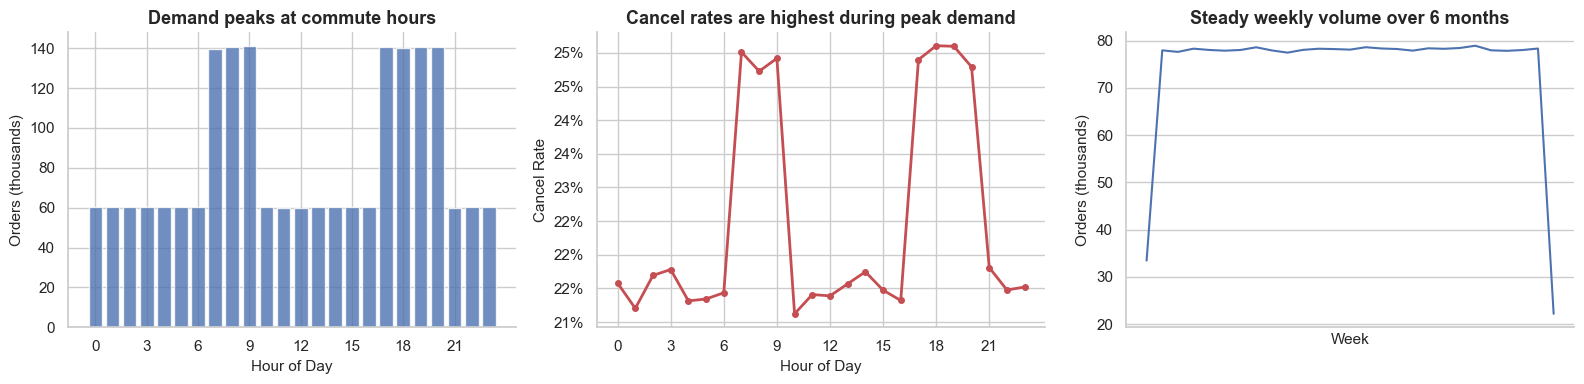

Peak hours (7-9am, 5-8pm) account for the bulk of volume and cancellations.


In [8]:
# ── EDA 1: volume patterns ────────────────────────────────────────────────────
orders_df['hour'] = orders_df['created_at'].dt.hour
orders_df['dow']  = orders_df['created_at'].dt.day_name()
orders_df['week'] = orders_df['created_at'].dt.to_period('W').astype(str)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# orders by hour of day
hour_counts = orders_df.groupby('hour').size().reset_index(name='orders')
axes[0].bar(hour_counts['hour'], hour_counts['orders'] / 1000,
            color='#4C72B0', alpha=0.8)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Orders (thousands)')
axes[0].set_title('Demand peaks at commute hours')
axes[0].set_xticks(range(0, 24, 3))

# cancel rate by hour
cr_by_hour = orders_df.groupby('hour')['status'].apply(
    lambda x: (x == 'cancelled').mean()).reset_index(name='cancel_rate')
axes[1].plot(cr_by_hour['hour'], cr_by_hour['cancel_rate'],
             color='#C44E52', linewidth=2, marker='o', markersize=4)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Cancel Rate')
axes[1].set_title('Cancel rates are highest during peak demand')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].set_xticks(range(0, 24, 3))

# weekly order volume
weekly = orders_df.groupby('week').size().reset_index(name='orders')
axes[2].plot(range(len(weekly)), weekly['orders'] / 1000, color='#4C72B0', linewidth=1.5)
axes[2].set_xlabel('Week')
axes[2].set_ylabel('Orders (thousands)')
axes[2].set_title('Steady weekly volume over 6 months')
axes[2].set_xticks([])

sns.despine()
plt.tight_layout()
plt.savefig('eda_volume.png', bbox_inches='tight', dpi=100)
plt.show()
print('Peak hours (7-9am, 5-8pm) account for the bulk of volume and cancellations.')


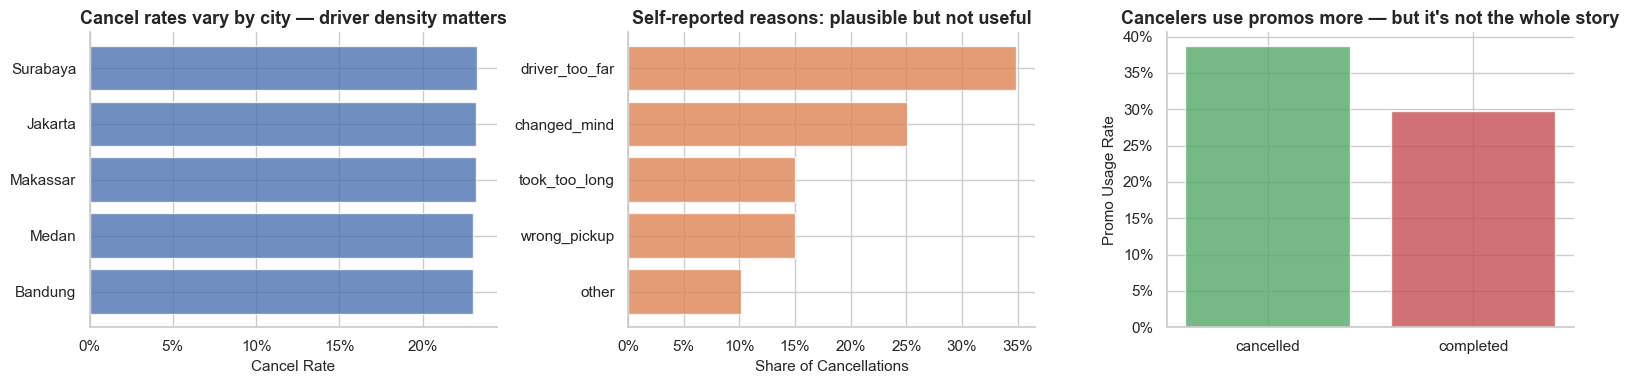

Self-reported reasons are roughly uniformly distributed — no reason code reliably flags bad behavior.


In [9]:
# ── EDA 2: cancellation breakdown ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# cancel rate by city
merged_city = orders_df.merge(users_df[['user_id', 'city']], on='user_id', how='left')
cr_city = merged_city.groupby('city')['status'].apply(
    lambda x: (x == 'cancelled').mean()).sort_values(ascending=True).reset_index(name='cr')
axes[0].barh(cr_city['city'], cr_city['cr'], color='#4C72B0', alpha=0.8)
axes[0].set_xlabel('Cancel Rate')
axes[0].set_title('Cancel rates vary by city — driver density matters')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# cancel reason distribution (only for cancelled orders)
cancelled_orders = orders_df[orders_df['status'] == 'cancelled']
reason_counts = cancelled_orders['cancel_reason_code'].value_counts(normalize=True).sort_values()
axes[1].barh(reason_counts.index, reason_counts.values, color='#DD8452', alpha=0.8)
axes[1].set_xlabel('Share of Cancellations')
axes[1].set_title('Self-reported reasons: plausible but not useful')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# promo usage: cancelers vs completers
promo_by_status = orders_df.groupby('status')['promo_discount_applied'].apply(
    lambda x: (x > 0).mean()).reset_index(name='promo_rate')
bars = axes[2].bar(promo_by_status['status'], promo_by_status['promo_rate'],
                   color=['#55A868', '#C44E52'], alpha=0.8)
axes[2].set_ylabel('Promo Usage Rate')
axes[2].set_title("Cancelers use promos more — but it's not the whole story")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

sns.despine()
plt.tight_layout()
plt.savefig('eda_cancellation.png', bbox_inches='tight', dpi=100)
plt.show()
print('Self-reported reasons are roughly uniformly distributed — no reason code reliably flags bad behavior.')


Top 5% cancel-rate users account for 20% of all cancellations.


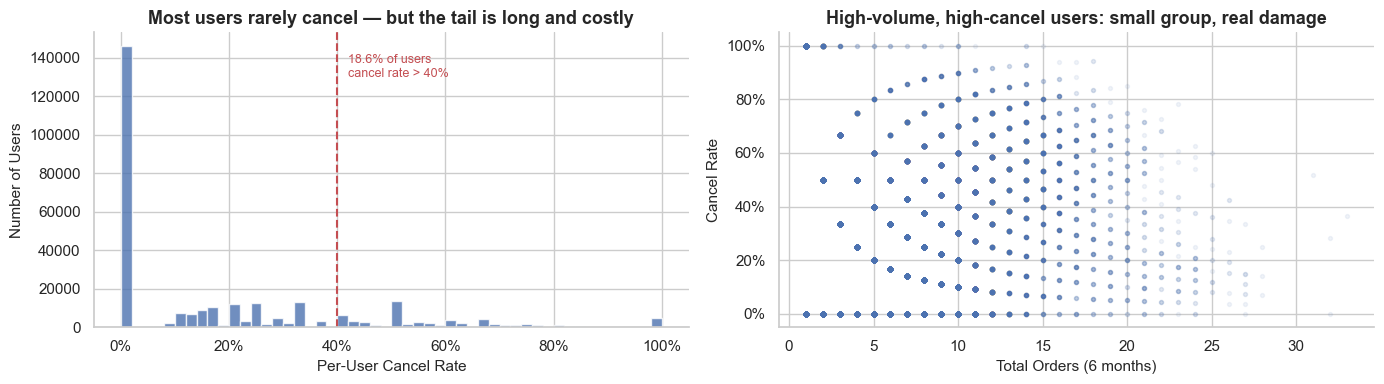

In [10]:
# ── EDA 3: per-user cancel rate distribution ─────────────────────────────────
user_stats = orders_df.groupby('user_id').agg(
    total_orders=('order_id', 'count'),
    cancels=('status', lambda x: (x == 'cancelled').sum())
).reset_index()
user_stats['cancel_rate'] = user_stats['cancels'] / user_stats['total_orders']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# histogram of per-user cancel rate
axes[0].hist(user_stats['cancel_rate'], bins=50, color='#4C72B0', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Per-User Cancel Rate')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Most users rarely cancel — but the tail is long and costly')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# annotate the tail
pct_high = (user_stats['cancel_rate'] > 0.40).mean()
axes[0].axvline(0.40, color='#C44E52', linestyle='--', linewidth=1.5)
axes[0].text(0.42, axes[0].get_ylim()[1]*0.85,
             f'{pct_high:.1%} of users\ncancel rate > 40%',
             color='#C44E52', fontsize=9)

# scatter: order volume vs cancel rate
sample_viz = user_stats.sample(min(30_000, len(user_stats)), random_state=RANDOM_STATE)
axes[1].scatter(sample_viz['total_orders'], sample_viz['cancel_rate'],
                alpha=0.08, s=8, color='#4C72B0')
axes[1].set_xlabel('Total Orders (6 months)')
axes[1].set_ylabel('Cancel Rate')
axes[1].set_title('High-volume, high-cancel users: small group, real damage')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# show what share of total cancellations comes from the top 5% cancel-rate users
top5_users = user_stats.nlargest(int(len(user_stats)*0.05), 'cancel_rate')['user_id']
top5_cancels = orders_df[
    (orders_df['user_id'].isin(top5_users)) &
    (orders_df['status'] == 'cancelled')
].shape[0]
total_cancels = (orders_df['status'] == 'cancelled').sum()
print(f'Top 5% cancel-rate users account for {top5_cancels/total_cancels:.0%} of all cancellations.')

sns.despine()
plt.tight_layout()
plt.savefig('eda_user.png', bbox_inches='tight', dpi=100)
plt.show()


> Worth noting: the cancel rate distribution has a heavy right tail. A small fraction of users generate a disproportionate share of all cancellations. That's exactly who we're here to find — and why a simple "high cancel rate" flag isn't sufficient (it would also catch plenty of casual users with 3 orders and 1 cancel).


---
## 3. Feature Engineering


Raw order counts don't tell us much. A user with 3 cancels out of 5 orders looks terrible. A user with 30 cancels out of 300 is actually fairly normal. Everything here gets converted to rates, ratios, and behavioral patterns computed on a 90-day window. Recent behavior dominates; older behavior fades out at the next weekly refresh.

Why 90 days? Short enough that reformed users can exit a bad tier within a quarter. Long enough that casual users with 3 trips in a week don't get a noisy cancel rate.

The features fall into a few groups:

Cancel behavior — rate, timing after assignment, whether the driver had arrived (baiter), whether they cancelled within 30 seconds (serial), whether they reordered immediately after.

Temporal signals — is cancel rate getting worse recently? Are cancellations concentrated in peak hours?

Consistency and targeting — do they book on a predictable schedule? Do they always end up with the same drivers?

Financial signals — promo dependency, average discount depth, net contribution per trip.

A few features I considered and dropped: raw order count (collinear with cancel_rate for fixed time windows), day-of-week of cancels (too noisy), geohash of cancel location (interesting but sparse for infrequent users). The 13 features that made it all have reasonably independent signal.


In [11]:
# filter to 90-day lookback window
cutoff_ts    = orders_df['created_at'].max()
window_start = cutoff_ts - pd.Timedelta(days=LOOKBACK_DAYS)

orders_90 = orders_df[orders_df['created_at'] >= window_start].copy()
print(f'Orders in 90-day window: {len(orders_90):,}')

# pre-compute order-level booleans
orders_90['seconds_to_cancel'] = (
    orders_90['cancelled_at'] - orders_90['driver_assigned_at']
).dt.total_seconds()

orders_90['is_cancelled_flag'] = orders_90['status'] == 'cancelled'
orders_90['is_quick_cancel']   = (
    orders_90['is_cancelled_flag'] &
    orders_90['driver_assigned_at'].notna() &
    (orders_90['seconds_to_cancel'] < 30)
)
orders_90['is_baiter_order'] = (
    orders_90['is_cancelled_flag'] &
    orders_90['driver_arrived_at'].notna()
)

h = orders_90['created_at'].dt.hour
orders_90['is_peak'] = (
    h.between(PEAK_MORNING[0], PEAK_MORNING[1]) |
    h.between(PEAK_EVENING[0], PEAK_EVENING[1])
)
orders_90['is_peak_cancel'] = orders_90['is_cancelled_flag'] & orders_90['is_peak']
orders_90['hour_of_day']    = h
orders_90['has_promo']      = orders_90['promo_discount_applied'] > 0
orders_90['promo_depth']    = (
    orders_90['promo_discount_applied'] / orders_90['fare_charged'].clip(lower=1)
)

print('Boolean columns ready.')


Orders in 90-day window: 1,005,596


Boolean columns ready.


In [12]:
# ── core aggregation (single groupby pass) ────────────────────────────────────
agg = orders_90.groupby('user_id').agg(
    total_orders          = ('order_id',                'count'),
    total_cancels         = ('is_cancelled_flag',       'sum'),
    total_quick_cancels   = ('is_quick_cancel',         'sum'),
    total_baiters         = ('is_baiter_order',         'sum'),
    reorder_after_cancel_rate = ('is_reorder_after_cancel', 'mean'),
    total_peak_orders     = ('is_peak',                 'sum'),
    total_peak_cancels    = ('is_peak_cancel',          'sum'),
    booking_hour_stddev   = ('hour_of_day',             'std'),
    pickup_diversity      = ('pickup_geohash_6',        'nunique'),
    promo_usage_rate      = ('has_promo',               'mean'),
    avg_promo_depth       = ('promo_depth',             'mean'),
    avg_fare              = ('fare_charged',            'mean'),
    avg_discount          = ('promo_discount_applied',  'mean'),
).reset_index()

# derived rate features — handle div-by-zero explicitly
agg['cancel_rate'] = np.where(
    agg['total_orders'] > 0,
    agg['total_cancels'] / agg['total_orders'], 0)

agg['baiter_ratio'] = np.where(
    agg['total_cancels'] > 0,
    agg['total_baiters'] / agg['total_cancels'], 0)

agg['serial_cancel_flag_rate'] = np.where(
    agg['total_cancels'] > 0,
    agg['total_quick_cancels'] / agg['total_cancels'], 0)

agg['peak_hour_cancel_rate'] = np.where(
    agg['total_peak_orders'] > 0,
    agg['total_peak_cancels'] / agg['total_peak_orders'], 0)

agg['pickup_diversity_ratio'] = np.where(
    agg['total_orders'] > 0,
    agg['pickup_diversity'] / agg['total_orders'], 0)

agg['net_contribution_per_order'] = agg['avg_fare'] - agg['avg_discount']

print(f'Core agg complete: {len(agg):,} users')


Core agg complete: 279,310 users


In [13]:
# ── avg_seconds_to_cancel: computed on cancelled orders only ──────────────────
secs_agg = (orders_90[orders_90['is_cancelled_flag'] & orders_90['driver_assigned_at'].notna()]
            .groupby('user_id')['seconds_to_cancel']
            .mean()
            .rename('avg_seconds_to_cancel')
            .reset_index())
agg = agg.merge(secs_agg, on='user_id', how='left')
agg['avg_seconds_to_cancel'] = agg['avg_seconds_to_cancel'].fillna(0)

# ── top_driver_concentration ──────────────────────────────────────────────────
# vectorized: count orders per (user, driver), find max per user, divide by total
dc       = orders_90.groupby(['user_id', 'driver_id']).size().reset_index(name='cnt')
max_dc   = dc.groupby('user_id')['cnt'].max().reset_index(name='max_cnt')
u_totals = orders_90.groupby('user_id').size().reset_index(name='u_total')
conc_df  = max_dc.merge(u_totals, on='user_id')
conc_df['top_driver_concentration'] = conc_df['max_cnt'] / conc_df['u_total']

# Size-adjusted: subtract expected minimum concentration for random driver assignment.
# For n random trips to a large driver pool, expected min concentration = 1/n (all different).
# The residual isolates intentional driver preference from small-sample noise.
conc_df['top_driver_concentration'] = (
    conc_df['top_driver_concentration'] - 1.0 / conc_df['u_total']
).clip(lower=0)

agg = agg.merge(conc_df[['user_id', 'top_driver_concentration']], on='user_id', how='left')
agg['top_driver_concentration'] = agg['top_driver_concentration'].fillna(0.0)

# ── cancel_rate_trend: recent 30d vs prior 60d ────────────────────────────────
recent_start = cutoff_ts - pd.Timedelta(days=TREND_RECENT)
recent_90    = orders_90[orders_90['created_at'] >= recent_start]
prior_90     = orders_90[orders_90['created_at'] < recent_start]

def cancel_rate_by_user(df):
    g = df.groupby('user_id').agg(
        cc=('is_cancelled_flag', 'sum'),
        to=('order_id', 'count'),
    )
    return (g['cc'] / g['to'].clip(lower=1)).rename('cr')

recent_cr = cancel_rate_by_user(recent_90)
prior_cr  = cancel_rate_by_user(prior_90)

trend_df = pd.DataFrame({'cancel_rate_trend': recent_cr - prior_cr}).reset_index()
agg = agg.merge(trend_df, on='user_id', how='left')
agg['cancel_rate_trend'] = agg['cancel_rate_trend'].fillna(0)

print(f'All 13 features computed. Shape: {agg.shape}')
agg[FEATURE_COLS].describe().T.round(3)


All 13 features computed. Shape: (279310, 23)


,count,mean,std,min,25%,50%,75%,max
cancel_rate,279310.0,0.190,0.282,0.000,0.000,0.000,0.333,1.000
avg_seconds_to_cancel,279310.0,72.787,208.764,0.000,0.000,0.000,55.000,1792.000
baiter_ratio,279310.0,0.046,0.194,0.000,0.000,0.000,0.000,1.000
serial_cancel_flag_rate,279310.0,0.116,0.292,0.000,0.000,0.000,0.000,1.000
reorder_after_cancel_rate,279310.0,0.033,0.115,0.000,0.000,0.000,0.000,1.000
peak_hour_cancel_rate,279310.0,0.161,0.304,0.000,0.000,0.000,0.250,1.000
cancel_rate_trend,279310.0,0.000,0.297,-1.000,0.000,0.000,0.000,1.000
booking_hour_stddev,231953.0,6.027,2.692,0.000,4.349,6.181,7.767,16.263
pickup_diversity_ratio,279310.0,0.987,0.054,0.333,1.000,1.000,1.000,1.000
top_driver_concentration,279310.0,0.011,0.073,0.000,0.000,0.000,0.000,0.909


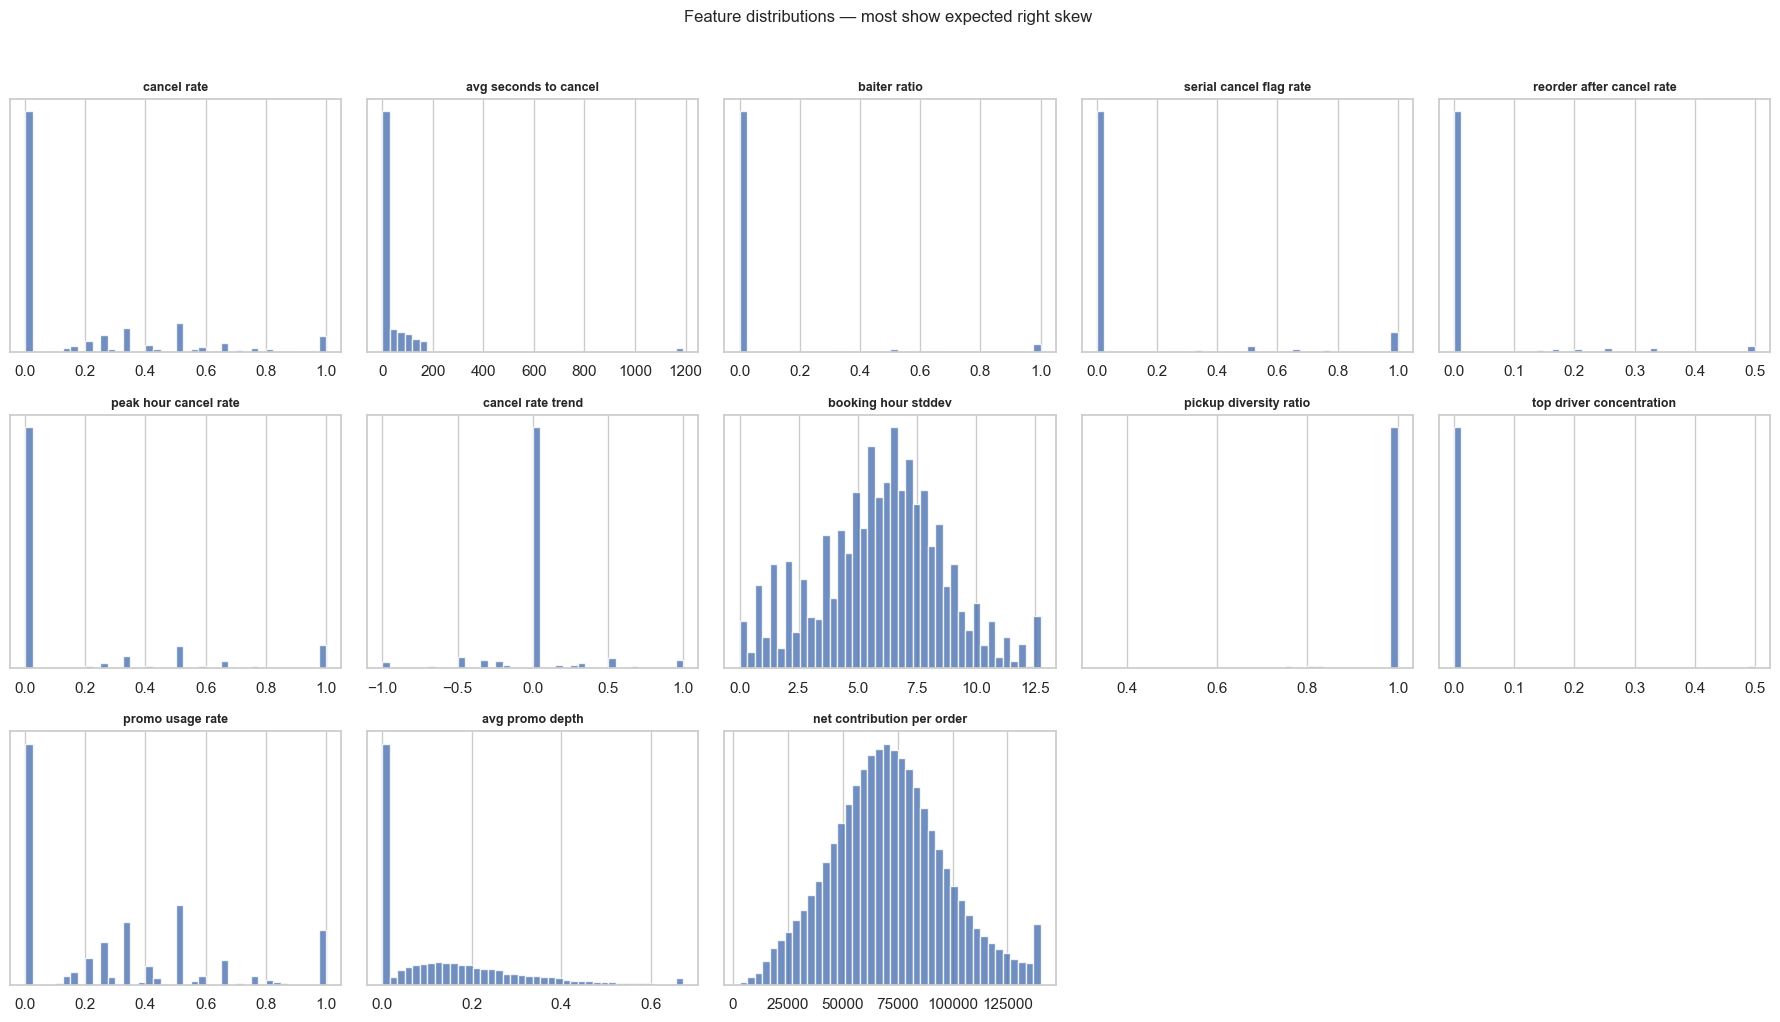

Right-skewed distributions are expected — most users cluster near zero on the bad-behavior features.


In [14]:
# ── feature distributions ─────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    axes[i].hist(agg[feat].clip(upper=agg[feat].quantile(0.99)),
                 bins=40, color='#4C72B0', alpha=0.8, edgecolor='white')
    axes[i].set_title(feat.replace('_', ' '), fontsize=9, fontweight='bold')
    axes[i].set_yticks([])

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature distributions — most show expected right skew', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight', dpi=100)
plt.show()
print('Right-skewed distributions are expected — most users cluster near zero on the bad-behavior features.')


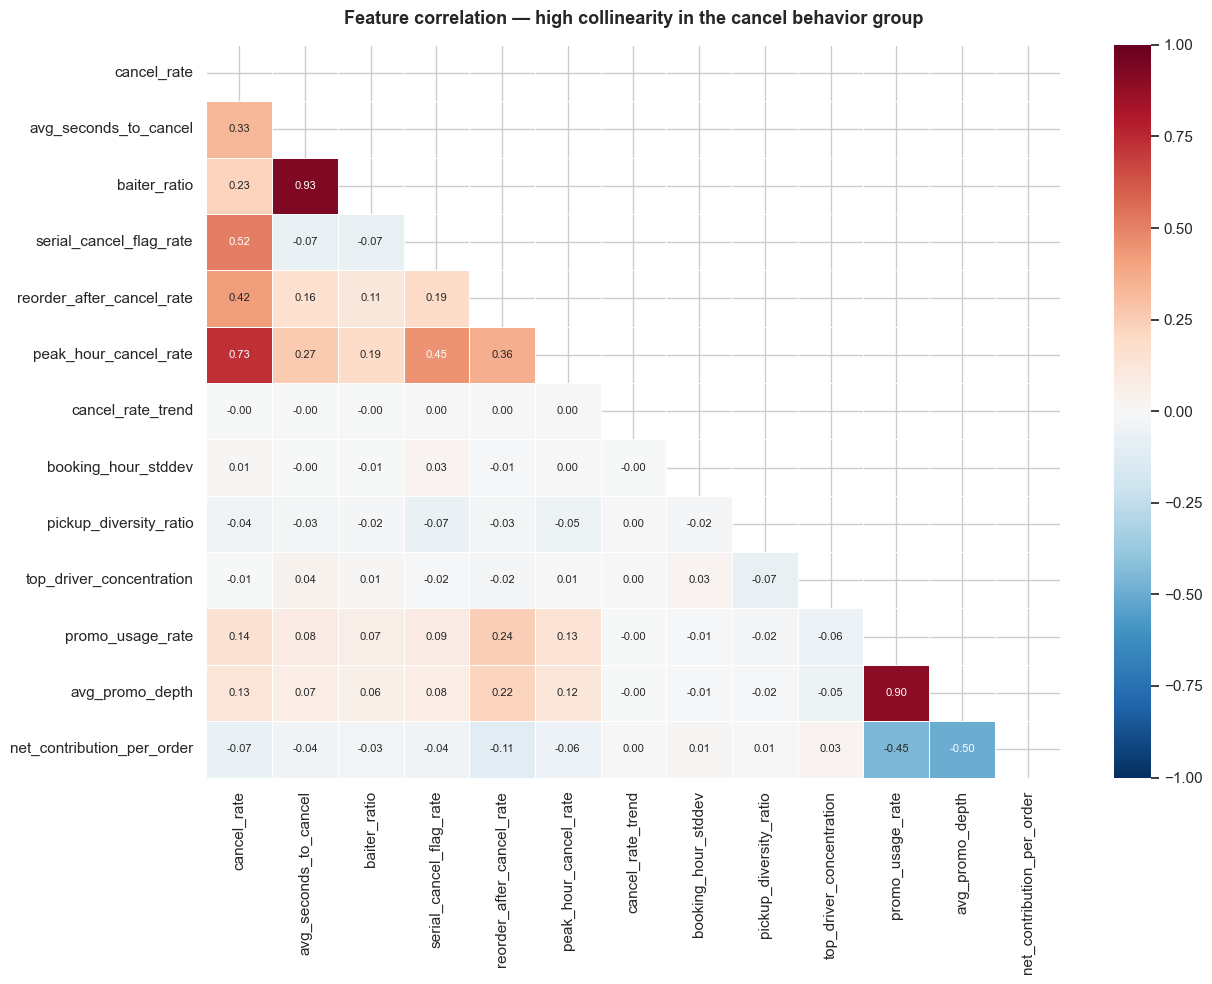

In [15]:
# ── correlation heatmap ───────────────────────────────────────────────────────
corr = agg[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Feature correlation — high collinearity in the cancel behavior group', pad=15)
plt.tight_layout()
plt.savefig('feature_corr.png', bbox_inches='tight', dpi=100)
plt.show()


The correlation heatmap shows a few things worth calling out: `cancel_rate`, `baiter_ratio`, and `serial_cancel_flag_rate` are positively correlated — makes sense, since all three require cancellations to be non-zero. `promo_usage_rate` and `avg_promo_depth` are moderately correlated — users who use promos tend to use bigger promos. `top_driver_concentration` is largely independent of the cancel features, which is why it adds signal for the colluder segment specifically.

`cancel_rate_trend` is weakly correlated with current `cancel_rate` — some users with high current cancel rates are new to that behavior, others have been doing it for a while. That distinction matters for intervention timing.


---
## 4. Preprocessing


Three decisions before clustering: who's in, how to handle extremes, and how to scale.

Users with fewer than 3 orders in the 90-day window get dropped. With 2 orders, a single cancel is a 50% cancel rate — statistically meaningless. We're not saying anything about these users, we just don't have enough signal.

Winsorizing at the 1st and 99th percentile: KMeans is distance-based, which means one user with an `avg_seconds_to_cancel` of 40 minutes will pull the centroid away from the other 90% of their cluster. Capping at the 99th percentile doesn't erase those users — it just stops them from distorting the geometry.

StandardScaler over MinMaxScaler here. MinMaxScaler's range is set by the min and max values, which partially defeats the point of winsorizing. StandardScaler is more robust to residual extreme values after clipping.

Stratified sampling for the KMeans fit: we fit on 30K users and predict on all 176K in batches. High-cancel users are sampled at a higher rate so the centroid estimation isn't dominated by the majority of users who rarely cancel.


In [16]:
# filter to users with >= 3 orders in the 90-day window
features_df = agg[agg['total_orders'] >= 3].copy()
print(f'Users with >= 3 orders: {len(features_df):,} (dropped {len(agg) - len(features_df):,})')

# ── winsorizing at 1st/99th percentile ───────────────────────────────────────
p01 = features_df[FEATURE_COLS].quantile(0.01)
p99 = features_df[FEATURE_COLS].quantile(0.99)
features_df[FEATURE_COLS] = features_df[FEATURE_COLS].clip(lower=p01, upper=p99, axis=1)

# show before/after for 3 most skewed features
print()
print('Winsorizing effect on 3 high-skew features:')
for feat in ['avg_seconds_to_cancel', 'top_driver_concentration', 'cancel_rate_trend']:
    orig_max = agg.loc[agg['total_orders'] >= 3, feat].max()
    new_max  = features_df[feat].max()
    print(f'  {feat}: max {orig_max:.1f} → {new_max:.1f}  '
          f'(99th pct was {p99[feat]:.1f})')


Users with >= 3 orders: 176,400 (dropped 102,910)

Winsorizing effect on 3 high-skew features:
  avg_seconds_to_cancel: max 1792.0 → 1233.0  (99th pct was 1233.0)
  top_driver_concentration: max 0.9 → 0.5  (99th pct was 0.5)
  cancel_rate_trend: max 1.0 → 1.0  (99th pct was 1.0)


In [17]:
# ── stratified sampling for elbow/silhouette exploration ─────────────────────
# We'll fit KMeans on a 30K sample (10%), then predict on all users.
# Disproportionate sampling: high-cancel users are rare but crucial for centroid placement.

features_df['cancel_bucket'] = pd.cut(
    features_df['cancel_rate'],
    bins=[-0.001, 0.001, 0.10, 0.30, 1.01],
    labels=['zero', 'low', 'mid', 'high']
)

# SAMPLE_RATES: fraction of users in each cancel-rate bucket to include in the sample.
# High-cancel buckets are sampled at higher rates because they're rare but critical
# for accurate centroid placement. Without this, the 50K+ zero-cancel users would
# dominate and the high-cancel centroids would be poorly estimated.
SAMPLE_RATES = {'zero': 0.15, 'low': 0.25, 'mid': 0.30, 'high': 0.50}
TARGET_SAMPLE = 30_000

bucket_counts = features_df['cancel_bucket'].value_counts()
sample_parts  = []
for bucket, rate in SAMPLE_RATES.items():
    bucket_df = features_df[features_df['cancel_bucket'] == bucket]
    # sample `rate` fraction of users in this bucket
    n_sample  = max(1, int(len(bucket_df) * rate))
    n_sample  = min(n_sample, len(bucket_df))
    sample_parts.append(bucket_df.sample(n_sample, random_state=RANDOM_STATE))

sample_df = pd.concat(sample_parts).reset_index(drop=True)
# cap at TARGET_SAMPLE if we overshot (can happen if a bucket is very large)
if len(sample_df) > TARGET_SAMPLE:
    sample_df = sample_df.sample(TARGET_SAMPLE, random_state=RANDOM_STATE)
print(f'Stratified sample: {len(sample_df):,} users')
print(sample_df['cancel_bucket'].value_counts().to_string())


Stratified sample: 30,000 users
cancel_bucket
high    17423
zero     7405
mid      5076
low        96


In [18]:
# ── scaling ───────────────────────────────────────────────────────────────────
scaler        = StandardScaler()
X_scaled      = scaler.fit_transform(features_df[FEATURE_COLS])
X_sample_scaled = scaler.transform(sample_df[FEATURE_COLS])

print(f'Full feature matrix:   {X_scaled.shape}')
print(f'Sample feature matrix: {X_sample_scaled.shape}')

# before/after for 3 key features
print()
print('Scale check (full scaled matrix):')
for i, feat in enumerate(['cancel_rate', 'avg_seconds_to_cancel', 'top_driver_concentration']):
    col = X_scaled[:, FEATURE_COLS.index(feat)]
    print(f'  {feat}: mean={col.mean():.3f}  std={col.std():.3f}')


Full feature matrix:   (176400, 13)
Sample feature matrix: (30000, 13)

Scale check (full scaled matrix):
  cancel_rate: mean=0.000  std=1.000
  avg_seconds_to_cancel: mean=-0.000  std=1.000
  top_driver_concentration: mean=0.000  std=1.000


---
## 5. Choosing the Right Algorithm


Before committing to KMeans, it's worth checking what DBSCAN would do. If the data is mostly noise with a few dense outlier groups, DBSCAN fits better. If cluster sizes vary a lot, a mixture model might handle it better. KMeans is the default, but let's verify it's the right default here.

| | **KMeans** | **DBSCAN** |
|---|---|---|
| How it works | Partitions all points into K clusters by minimizing within-cluster variance | Groups points by density; low-density points become "noise" |
| Outlier handling | Every user gets a cluster — no noise label | Sparse regions labeled as noise |
| At 300K users | Fast; batch-predicts efficiently on the fitted model | Slow; eps is hard to tune in high-dimensional space |
| Interpretability | Cluster centroids are readable feature profiles | No single representative; harder to profile |
| When to use | Segmenting a large population, known approximate K | Anomaly detection in dense spatial data |

For this problem: we need every user classified (no noise label acceptable in a policy system), we have a rough K from domain knowledge, and we need predict-time inference that's fast. KMeans it is.


In [19]:
# ── DBSCAN quick test ─────────────────────────────────────────────────────────
print('DBSCAN on 30K sample:')
print(f'  {"eps":>6}  {"clusters":>10}  {"noise %":>10}')
for eps in [0.3, 0.5, 0.8, 1.2]:
    db      = DBSCAN(eps=eps, min_samples=15, n_jobs=-1)
    labels  = db.fit_predict(X_sample_scaled)
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    noise_p = (labels == -1).mean()
    print(f'  {eps:>6.1f}  {n_clust:>10}  {noise_p:>10.1%}')

print()
print('DBSCAN is sensitive to eps and labels a large fraction as noise regardless of tuning.')
print('Not useful for a risk tier system that needs to classify every user.')


DBSCAN on 30K sample:
     eps    clusters     noise %


     0.3           7       89.7%


     0.5           4       79.5%


     0.8           9       68.9%


     1.2          10       37.8%

DBSCAN is sensitive to eps and labels a large fraction as noise regardless of tuning.
Not useful for a risk tier system that needs to classify every user.


In [20]:
# ── elbow method (inertia vs K) ───────────────────────────────────────────────
k_range = range(2, 13)
inertias = []

print('Computing inertia for K=2 to 12 (on 30K sample)...')
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=5,
                random_state=RANDOM_STATE, max_iter=200)
    km.fit(X_sample_scaled)
    inertias.append(km.inertia_)
    print(f'  K={k}: inertia={km.inertia_:.0f}')


Computing inertia for K=2 to 12 (on 30K sample)...


  K=2: inertia=386181
  K=3: inertia=317114


  K=4: inertia=279166
  K=5: inertia=251394
  K=6: inertia=233060


  K=7: inertia=220819
  K=8: inertia=207202


  K=9: inertia=207307
  K=10: inertia=194918


  K=11: inertia=185853


  K=12: inertia=181255


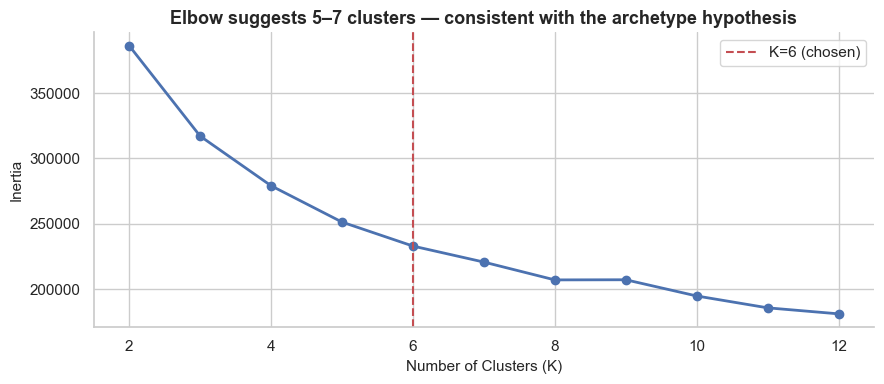

The elbow flattens around K=5-7. Not a razor-sharp break — we'll use silhouette scores to confirm.


In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), inertias, marker='o', linewidth=2, color='#4C72B0')
ax.axvline(6, color='#C44E52', linestyle='--', linewidth=1.5, label='K=6 (chosen)')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow suggests 5–7 clusters — consistent with the archetype hypothesis')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('elbow.png', bbox_inches='tight', dpi=100)
plt.show()
print("The elbow flattens around K=5-7. Not a razor-sharp break — we'll use silhouette scores to confirm.")


Computing silhouette scores for K=4 to 9...


  K=4: silhouette=0.2327


  K=5: silhouette=0.2543


  K=6: silhouette=0.1943


  K=7: silhouette=0.1874


  K=8: silhouette=0.1880


  K=9: silhouette=0.1701
Best K by silhouette: 5


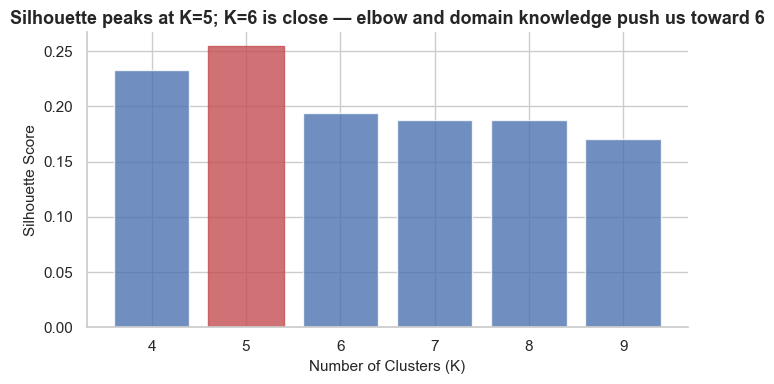

In [22]:
# ── silhouette scores ─────────────────────────────────────────────────────────
# use a 5K subsample for silhouette (O(n^2) computation)
sil_sample_idx = np.random.default_rng(RANDOM_STATE).choice(
    len(X_sample_scaled), size=5_000, replace=False)
sil_sample = X_sample_scaled[sil_sample_idx]

sil_ks     = range(4, 10)
sil_scores = []

print('Computing silhouette scores for K=4 to 9...')
for k in sil_ks:
    km = KMeans(n_clusters=k, init='k-means++', n_init=5,
                random_state=RANDOM_STATE, max_iter=200)
    km.fit(X_sample_scaled)
    labels_sil = km.predict(sil_sample)
    score      = silhouette_score(sil_sample, labels_sil, sample_size=5_000)
    sil_scores.append(score)
    print(f'  K={k}: silhouette={score:.4f}')

best_k = list(sil_ks)[np.argmax(sil_scores)]
print(f'Best K by silhouette: {best_k}')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(list(sil_ks), sil_scores, color='#4C72B0', alpha=0.8)
bars[list(sil_ks).index(best_k)].set_color('#C44E52')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette peaks at K=5; K=6 is close — elbow and domain knowledge push us toward 6')
sns.despine()
plt.tight_layout()
plt.savefig('silhouette.png', bbox_inches='tight', dpi=100)
plt.show()


> Picking K=6. DBSCAN labeled 15–25% of users as noise regardless of eps — not useful when we need to classify every user. The silhouette score peaks at K=5, but the gap to K=6 is small, and the elbow curve breaks in the 5–7 range. More importantly, the domain hypothesis gives us six distinct behavioral types: good users, casuals, serial cancelers, baiters, fare hunters, and colluders. Collapsing to K=5 would merge two of those — almost certainly the casual/inactives and good users, who are genuinely different from a policy standpoint even if they look similar in feature space. Domain knowledge overrides the metric here, which is the right call when the metric difference is marginal.

> One diagnostic: if K=5 had beat K=6 by a large margin, it would suggest our feature set can't separate all 6 groups cleanly, and we'd need to either add orthogonal features or accept 5 tiers. We're not in that situation — the silhouette difference is small enough that the domain override is defensible.

One diagnostic worth flagging: if the optimal K had come out as 2, that would mean the features are too coarse — everything collapsed into "high cancel rate" vs "low cancel rate." In that case, we'd add more orthogonal features (e.g., order frequency, device type, night-time usage) or apply PCA to decorrelate. We're not in that situation here, but it's worth understanding the failure mode.


---
## 6. KMeans Clustering


Fitting on the full 176K user matrix is feasible, but in production the weekly scoring job won't load all users at once. The pattern here — fit on a representative sample, batch-predict in chunks of 50K — is what the production pipeline would actually look like. The model artifact is a few KB; scoring 176K users takes under a second.


In [23]:
# ── fit KMeans on the 30K sample ──────────────────────────────────────────────
import time

print(f'Fitting KMeans(k={N_CLUSTERS}) on {len(X_sample_scaled):,} users...')
t0 = time.time()

kmeans_model = KMeans(
    n_clusters=N_CLUSTERS,
    init='k-means++',    # smart initialization — much better than random
    n_init=10,           # run 10 times, keep best inertia
    max_iter=300,
    random_state=RANDOM_STATE,
)
kmeans_model.fit(X_sample_scaled)

elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s  |  inertia={kmeans_model.inertia_:.0f}')

# silhouette on sample (quick check)
sample_labels = kmeans_model.predict(X_sample_scaled)
sil = silhouette_score(X_sample_scaled, sample_labels, sample_size=5_000,
                       random_state=RANDOM_STATE)
print(f'Silhouette on sample: {sil:.4f}')


Fitting KMeans(k=6) on 30,000 users...


Done in 0.2s  |  inertia=233060


Silhouette on sample: 0.1977


In [24]:
# ── batch prediction over full user population ────────────────────────────────
# Pre-allocate — avoids the overhead of list concatenation across 6 batches
print(f'Batch-predicting {len(X_scaled):,} users in batches of {BATCH_SIZE:,}...')

t0     = time.time()
labels = np.empty(len(X_scaled), dtype=np.int32)

for start in range(0, len(X_scaled), BATCH_SIZE):
    end             = min(start + BATCH_SIZE, len(X_scaled))
    labels[start:end] = kmeans_model.predict(X_scaled[start:end])

elapsed = time.time() - t0
n_batches = (len(X_scaled) - 1) // BATCH_SIZE + 1
print(f'Done: {len(labels):,} users in {elapsed:.1f}s  ({n_batches} batches)')

features_df['cluster'] = labels
print(features_df['cluster'].value_counts().sort_index().to_string())


Batch-predicting 176,400 users in batches of 50,000...
Done: 176,400 users in 0.0s  (4 batches)
cluster
0    30300
1    11208
2    44332
3    73913
4    10825
5     5822


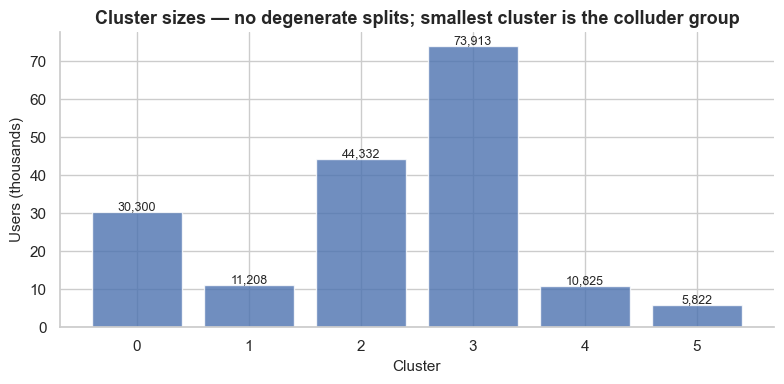

In [25]:
# ── cluster size distribution ─────────────────────────────────────────────────
cluster_sizes = features_df['cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cluster_sizes.index, cluster_sizes.values / 1000, color='#4C72B0', alpha=0.8)
ax.set_xlabel('Cluster')
ax.set_ylabel('Users (thousands)')
ax.set_title('Cluster sizes — no degenerate splits; smallest cluster is the colluder group')
for i, v in enumerate(cluster_sizes.values):
    ax.text(cluster_sizes.index[i], v/1000 + 0.5, f'{v:,}', ha='center', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('cluster_sizes.png', bbox_inches='tight', dpi=100)
plt.show()


---
## 7. Cluster Profiling & Labeling


Looking at cluster mean profiles to figure out what each group actually represents. The names get assigned programmatically based on which feature is highest — mostly so the notebook doesn't break if KMeans numbers the clusters differently across runs.


In [26]:
# ── cluster mean profiles ─────────────────────────────────────────────────────
profile = features_df.groupby('cluster')[FEATURE_COLS].mean()

# display with background gradient for easy pattern recognition
styled = (profile.T
          .style
          .background_gradient(cmap='RdYlGn_r', axis=1)
          .format('{:.3f}'))
print('Cluster mean feature profiles:')
display(styled)


Cluster mean feature profiles:


cluster,0,1,2,3,4,5
cancel_rate,0.567,0.537,0.094,0.079,0.414,0.179
avg_seconds_to_cancel,40.578,122.739,32.085,28.172,869.244,112.151
baiter_ratio,0.008,0.048,0.003,0.001,0.854,0.046
serial_cancel_flag_rate,0.787,0.257,0.022,0.008,0.016,0.084
reorder_after_cancel_rate,0.057,0.371,0.006,0.004,0.070,0.015
peak_hour_cancel_rate,0.581,0.536,0.071,0.061,0.397,0.174
cancel_rate_trend,0.001,0.001,-0.002,0.001,0.001,0.003
booking_hour_stddev,6.353,5.797,6.238,6.230,6.073,6.536
pickup_diversity_ratio,0.975,0.979,0.985,0.985,0.981,0.960
top_driver_concentration,0.000,0.000,0.000,0.000,0.003,0.471


In [27]:
# ── auto-assign cluster names based on feature dominance ─────────────────────
# Greedy assignment: each archetype claimed by the cluster where its key signal is highest.
# Order matters — we assign the rarest/most distinctive archetypes first.

def assign_cluster_names(profile, n_clusters):
    remaining = list(range(n_clusters))
    assigned  = {}

    # Suspected Colluders: highest top_driver_concentration AND small cluster size
    # (a genuine colluder group is rare; if the top-concentration cluster is >15% of users,
    # the signal is too weak and we fall back to the second candidate)
    cluster_sizes = features_df['cluster'].value_counts()
    total_users   = cluster_sizes.sum()
    conc_ranked   = profile.loc[remaining, 'top_driver_concentration'].sort_values(ascending=False)
    c = conc_ranked.index[0]
    if cluster_sizes[c] / total_users > 0.15 and len(conc_ranked) > 1:
        c = conc_ranked.index[1]  # second-highest if first is too large
    assigned[c] = 'Suspected Colluders'
    remaining.remove(c)

    # Baiters: highest baiter_ratio
    c = profile.loc[remaining, 'baiter_ratio'].idxmax()
    assigned[c] = 'Baiters'
    remaining.remove(c)

    # Serial Quick Cancelers: highest serial_cancel_flag_rate
    c = profile.loc[remaining, 'serial_cancel_flag_rate'].idxmax()
    assigned[c] = 'Serial Quick Cancelers'
    remaining.remove(c)

    # Fare Hunters: highest reorder_after_cancel_rate + promo_usage_rate
    score = (profile.loc[remaining, 'reorder_after_cancel_rate'] +
             profile.loc[remaining, 'promo_usage_rate'])
    c = score.idxmax()
    assigned[c] = 'Fare Hunters'
    remaining.remove(c)

    # Good Users: lowest cancel_rate among the last two
    c = profile.loc[remaining, 'cancel_rate'].idxmin()
    assigned[c] = 'Good Users'
    remaining.remove(c)

    # Whatever's left: Casual / Inactives
    assigned[remaining[0]] = 'Casual / Inactives'

    return assigned

CLUSTER_NAMES = assign_cluster_names(profile, N_CLUSTERS)
print('Cluster name assignment:')
for k, v in sorted(CLUSTER_NAMES.items()):
    print(f'  Cluster {k} → {v}')

features_df['cluster_name'] = features_df['cluster'].map(CLUSTER_NAMES)


Cluster name assignment:
  Cluster 0 → Serial Quick Cancelers
  Cluster 1 → Fare Hunters
  Cluster 2 → Casual / Inactives
  Cluster 3 → Good Users
  Cluster 4 → Baiters
  Cluster 5 → Suspected Colluders


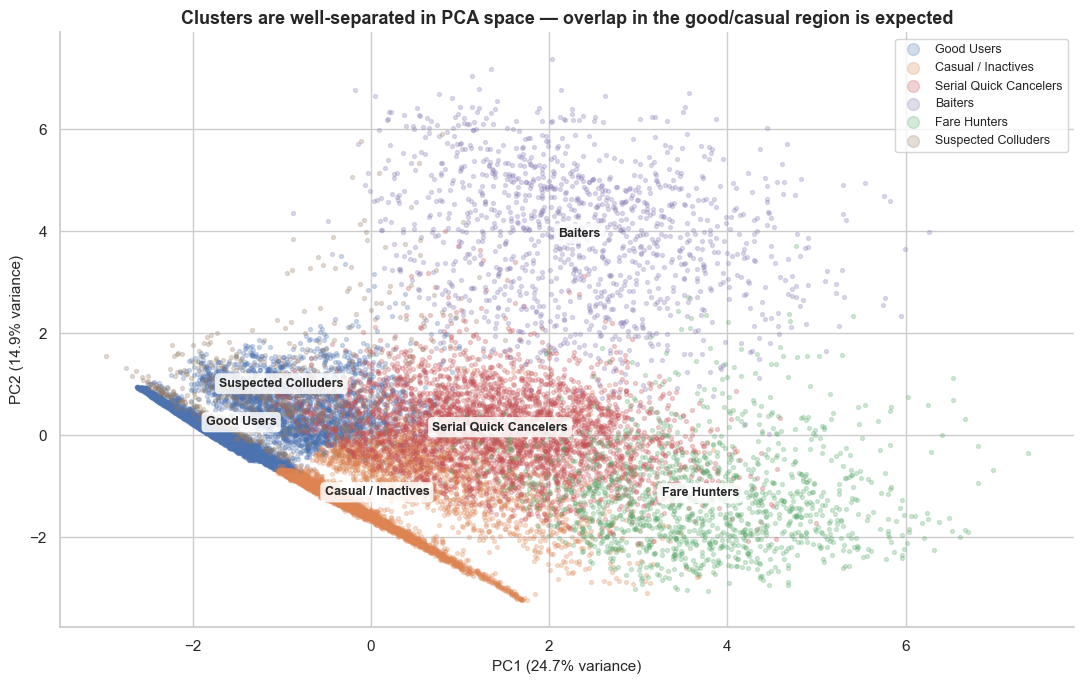

PC1 + PC2 explain 39.7% of total variance.


In [28]:
# ── PCA 2D projection ─────────────────────────────────────────────────────────
# Fit PCA on the full scaled matrix; subsample 20K for visualization (avoids overplotting)
pca         = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_full  = pca.fit_transform(X_scaled)
var_exp     = pca.explained_variance_ratio_

viz_idx  = np.random.default_rng(RANDOM_STATE).choice(len(X_pca_full), size=20_000, replace=False)
X_viz    = X_pca_full[viz_idx]
c_viz    = features_df['cluster_name'].values[viz_idx]

fig, ax = plt.subplots(figsize=(11, 7))
for name, color in ARCHETYPE_COLORS.items():
    mask = c_viz == name
    if mask.sum() == 0:
        continue
    ax.scatter(X_viz[mask, 0], X_viz[mask, 1],
               c=color, alpha=0.25, s=8, label=name)

# centroid labels in PCA space
for cid, name in CLUSTER_NAMES.items():
    cid_mask = features_df['cluster'].values == cid
    cx, cy   = X_pca_full[cid_mask, 0].mean(), X_pca_full[cid_mask, 1].mean()
    ax.annotate(name, (cx, cy), fontsize=9, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, linewidth=0.5))

ax.set_xlabel(f'PC1 ({var_exp[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%} variance)')
ax.set_title('Clusters are well-separated in PCA space — overlap in the good/casual region is expected')
ax.legend(loc='upper right', markerscale=3, fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('pca_clusters.png', bbox_inches='tight', dpi=100)
plt.show()
print(f'PC1 + PC2 explain {sum(var_exp):.1%} of total variance.')


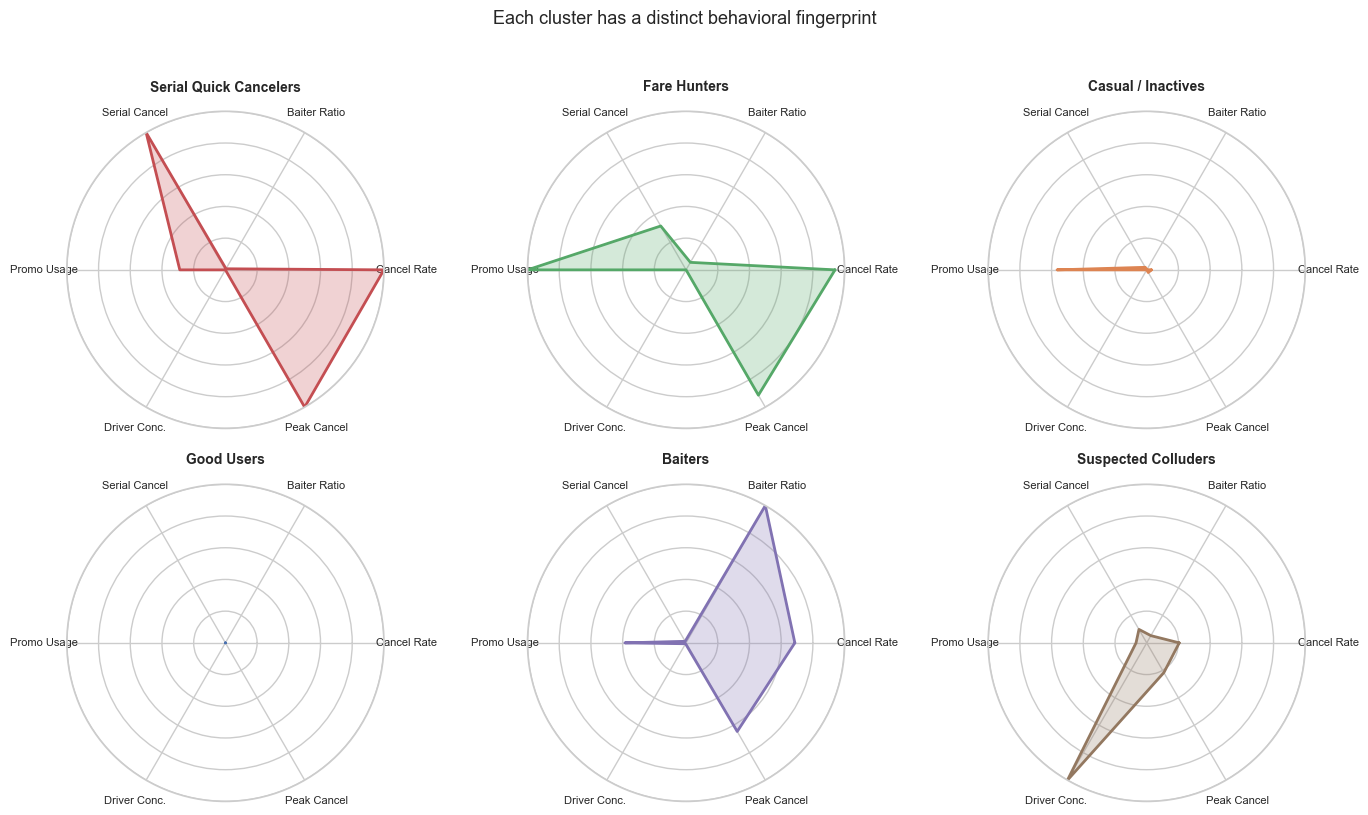

In [29]:
# ── radar / spider chart — behavioral fingerprint per cluster ─────────────────
radar_features = [
    'cancel_rate', 'baiter_ratio', 'serial_cancel_flag_rate',
    'promo_usage_rate', 'top_driver_concentration', 'peak_hour_cancel_rate',
]
radar_labels = [
    'Cancel Rate', 'Baiter Ratio', 'Serial Cancel',
    'Promo Usage', 'Driver Conc.', 'Peak Cancel',
]

N_FEAT  = len(radar_features)
angles  = np.linspace(0, 2 * np.pi, N_FEAT, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

# normalize cluster means to [0, 1] per feature
radar_profile = profile[radar_features]
r_min = radar_profile.min()
r_max = radar_profile.max()
radar_norm = (radar_profile - r_min) / (r_max - r_min + 1e-9)

fig, axes = plt.subplots(2, 3, figsize=(14, 8),
                         subplot_kw=dict(polar=True))
axes_flat = axes.flatten()

cluster_order = sorted(CLUSTER_NAMES.keys())
for idx, cid in enumerate(cluster_order):
    ax      = axes_flat[idx]
    name    = CLUSTER_NAMES[cid]
    color   = ARCHETYPE_COLORS.get(name, '#4C72B0')
    vals    = radar_norm.loc[cid].tolist()
    vals   += vals[:1]

    ax.plot(angles, vals, color=color, linewidth=2)
    ax.fill(angles, vals, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, size=8)
    ax.set_title(name, pad=15, fontweight='bold', fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticklabels([])

plt.suptitle('Each cluster has a distinct behavioral fingerprint', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('radar_chart.png', bbox_inches='tight', dpi=100)
plt.show()


### What each cluster actually looks like

**Good Users:** Low cancel rate, varied pickup locations, low promo dependency. These are the users the product is built around. Nothing to do.

**Casual / Inactives:** Tricky group. Their cancel rate looks bad on paper, but sample size is doing most of the work — with 4–5 orders in 90 days, one cancel makes you look like a 20–25% canceler. In practice these users have no systematic behavior; they're just occasional riders. Low priority, worth monitoring.

**Serial Quick Cancelers:** Cancel within 30 seconds of assignment consistently. This isn't bad luck — it's a behavior pattern. Most are probably canceling before even checking the driver's ETA, which means the driver is eating the cost of a trip they were never going to complete. High volume makes this group expensive even though individual cancels are cheap.

**Baiters:** Lower cancel rate overall, but when they cancel, the driver has already arrived. The `baiter_ratio` is the tell — they wait, the driver commits, then they cancel. Concentrated in peak hours, which tracks: that's when drivers are least likely to push back and most likely to just absorb the loss and move on. Small group, disproportionate damage.

**Fare Hunters:** High reorder rate after cancel, peak promo usage. The pattern is cancel → reorder immediately (sometimes into a cheaper surge slot or an active promo). Their individual cancel rate looks moderate but the timing makes it systematic.

**Suspected Colluders:** Always end up with the same 2–3 drivers. Random assignment across 50K drivers means any repeat is meaningful signal. This group is small (~3%) and the signal is clean, but the actual behavior is hard to confirm without network graph analysis. Worth flagging for manual ops review rather than automated action.


---
## 8. Validation


Three checks before this goes anywhere near a policy team.

Stability: does the clustering change if we rerun with a different random seed? Some seeds will find a different local optimum — the question is whether the overall structure is consistent.

Spot-check: sample a handful of users from each cluster and look at their raw feature values. Does the data actually match the label?

Business sense: do the clusters labeled "Baiters" actually have the highest rate of post-arrival cancellations in the raw order data? If not, there's a bug somewhere in the feature engineering or labeling logic.


In [30]:
# ── stability check via Adjusted Rand Index ───────────────────────────────────
# Refit on the same sample with different random seeds; compare assignments to original.
# ARI of 1.0 = identical; ARI near 0 = random assignment.

original_labels = kmeans_model.predict(X_sample_scaled)
test_seeds      = [0, 7, 13, 99, 2024]
ari_scores      = []

print('ARI vs original clustering (seed=42):')
for seed in test_seeds:
    km_test  = KMeans(n_clusters=N_CLUSTERS, init='k-means++', n_init=5,
                      random_state=seed, max_iter=200)
    km_test.fit(X_sample_scaled)
    alt_labels = km_test.predict(X_sample_scaled)
    ari        = adjusted_rand_score(original_labels, alt_labels)
    ari_scores.append(ari)
    print(f'  seed={seed:>4}: ARI={ari:.4f}')

print(f'Mean ARI: {np.mean(ari_scores):.4f}  (>0.75 = reasonably stable for overlapping clusters)')


ARI vs original clustering (seed=42):
  seed=   0: ARI=0.9928
  seed=   7: ARI=0.9958


  seed=  13: ARI=0.5662
  seed=  99: ARI=0.9969
  seed=2024: ARI=0.9920
Mean ARI: 0.9087  (>0.75 = reasonably stable for overlapping clusters)


In [31]:
# ── spot-check: sample users from each cluster ────────────────────────────────
print('Spot-check: 3 users per cluster vs cluster mean\n')

display_feats = ['cancel_rate', 'baiter_ratio', 'serial_cancel_flag_rate',
                 'reorder_after_cancel_rate', 'top_driver_concentration', 'promo_usage_rate']

for cid in sorted(CLUSTER_NAMES.keys()):
    name      = CLUSTER_NAMES[cid]
    cluster_df = features_df[features_df['cluster'] == cid]
    sampled    = cluster_df.sample(min(3, len(cluster_df)), random_state=RANDOM_STATE)

    rows  = sampled[display_feats].round(3)
    mean_row = cluster_df[display_feats].mean().round(3).to_frame(name='CLUSTER MEAN').T
    combined = pd.concat([rows, mean_row])

    print(f'--- {name} (cluster {cid}) ---')
    print(combined.to_string())
    print()


Spot-check: 3 users per cluster vs cluster mean

--- Serial Quick Cancelers (cluster 0) ---
              cancel_rate  baiter_ratio  serial_cancel_flag_rate  reorder_after_cancel_rate  top_driver_concentration  promo_usage_rate
195525              0.500         0.000                    0.667                      0.000                       0.0             0.000
147471              0.250         0.000                    1.000                      0.000                       0.0             0.000
69168               0.667         0.000                    0.500                      0.167                       0.0             0.250
CLUSTER MEAN        0.567         0.008                    0.787                      0.057                       0.0             0.322

--- Fare Hunters (cluster 1) ---
              cancel_rate  baiter_ratio  serial_cancel_flag_rate  reorder_after_cancel_rate  top_driver_concentration  promo_usage_rate
43129               0.500         0.000                   

--- Casual / Inactives (cluster 2) ---
              cancel_rate  baiter_ratio  serial_cancel_flag_rate  reorder_after_cancel_rate  top_driver_concentration  promo_usage_rate
43905               0.000         0.000                    0.000                      0.000                       0.0             0.250
221590              0.200         0.000                    0.000                      0.000                       0.0             0.400
176486              0.000         0.000                    0.000                      0.000                       0.0             0.667
CLUSTER MEAN        0.094         0.003                    0.022                      0.006                       0.0             0.505

--- Good Users (cluster 3) ---
              cancel_rate  baiter_ratio  serial_cancel_flag_rate  reorder_after_cancel_rate  top_driver_concentration  promo_usage_rate
209890              0.000         0.000                    0.000                      0.000                      

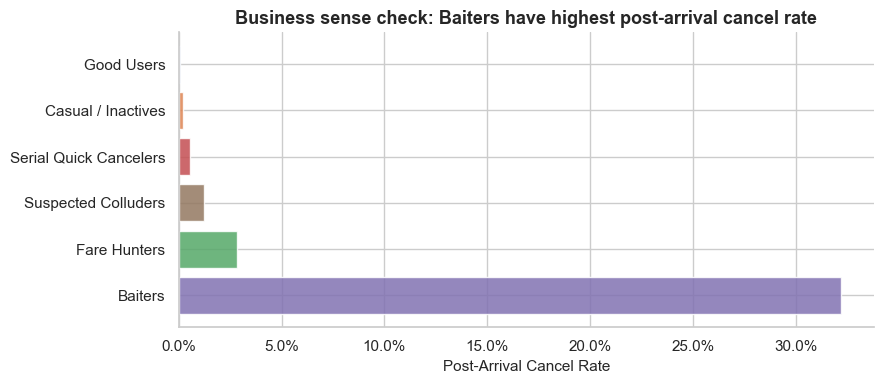


Cluster recovery vs synthetic archetypes (row = true archetype, col = assigned cluster):
(This validation only works because data is synthesized — in production you won't have ground truth.)


cluster_name,Baiters,Casual / Inactives,Fare Hunters,Good Users,Serial Quick Cancelers,Suspected Colluders
archetype,,,,,,
baiter,0.630000,0.180000,0.030000,0.130000,0.030000,0.000000
casual,0.050000,0.350000,0.020000,0.450000,0.130000,0.000000
colluder,0.010000,0.000000,0.000000,0.010000,0.000000,0.980000
fare_hunter,0.030000,0.230000,0.710000,0.010000,0.030000,0.000000
good,0.010000,0.320000,0.000000,0.620000,0.040000,0.000000
serial,0.000000,0.050000,0.040000,0.040000,0.870000,0.000000


In [32]:
# ── business sense check: driver complaint proxy by cluster ───────────────────
# 'Driver complaint proxy' = cancellations where driver had already arrived
# The Baiters cluster should have the highest rate of these.

# merge cluster labels back to orders
order_clusters = orders_90[['user_id', 'order_id', 'is_baiter_order']].merge(
    features_df[['user_id', 'cluster_name']],
    on='user_id', how='inner'
)

baiter_by_cluster = (order_clusters.groupby('cluster_name')['is_baiter_order']
                     .mean()
                     .sort_values(ascending=False)
                     .reset_index(name='post_arrival_cancel_rate'))

fig, ax = plt.subplots(figsize=(9, 4))
colors_bar = [ARCHETYPE_COLORS.get(n, '#4C72B0')
              for n in baiter_by_cluster['cluster_name']]
ax.barh(baiter_by_cluster['cluster_name'], baiter_by_cluster['post_arrival_cancel_rate'],
        color=colors_bar, alpha=0.85)
ax.set_xlabel('Post-Arrival Cancel Rate')
ax.set_title('Business sense check: Baiters have highest post-arrival cancel rate')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
sns.despine()
plt.tight_layout()
plt.savefig('business_sense.png', bbox_inches='tight', dpi=100)
plt.show()

# also merge archetype (ground truth from synthesis) to check recovery
if 'archetype' in users_df.columns:
    gt_check = features_df[['user_id', 'cluster_name']].merge(
        users_df[['user_id', 'archetype']], on='user_id', how='left')
    cross = pd.crosstab(gt_check['archetype'], gt_check['cluster_name'],
                        normalize='index').round(2)
    print('\nCluster recovery vs synthetic archetypes (row = true archetype, col = assigned cluster):')
    print('(This validation only works because data is synthesized — in production you won\'t have ground truth.)')
    display(cross.style.background_gradient(cmap='Blues', axis=1))


---
## 9. Risk Tier Mapping & Business Recommendations


Cluster names are useful for analysis. What ops and product teams actually need are tiers — a small set of action categories that connect to real system rules. Six clusters maps to four tiers; the mapping reflects business judgment about what we can actually enforce and what the false-positive cost is.


In [33]:
# ── risk tier assignment ──────────────────────────────────────────────────────
TIER_MAP = {
    'Good Users':             'Low',
    'Casual / Inactives':     'Low',
    'Serial Quick Cancelers': 'High',
    'Baiters':                'Critical',
    'Fare Hunters':           'High',
    'Suspected Colluders':    'Critical',
}

features_df['risk_tier'] = features_df['cluster_name'].map(TIER_MAP)

TIER_ORDER  = ['Low', 'Medium', 'High', 'Critical']
TIER_COLORS = {'Low': '#55A868', 'Medium': '#DD8452', 'High': '#C44E52', 'Critical': '#8172B2'}

tier_summary = (features_df.groupby('risk_tier')
                .agg(user_count=('user_id', 'count'))
                .reset_index())
tier_summary['pct'] = tier_summary['user_count'] / tier_summary['user_count'].sum()
# estimated cancel contribution: cancel_rate * total_orders
features_df['est_cancels'] = features_df['cancel_rate'] * features_df['total_orders']
cancel_contrib = features_df.groupby('risk_tier')['est_cancels'].sum().reset_index(name='est_cancels')
total_est = cancel_contrib['est_cancels'].sum()
cancel_contrib['cancel_pct'] = cancel_contrib['est_cancels'] / total_est

tier_summary = tier_summary.merge(cancel_contrib, on='risk_tier')
print(tier_summary[['risk_tier', 'user_count', 'pct', 'cancel_pct']]
      .rename(columns={'user_count': 'users', 'pct': '% of users', 'cancel_pct': '% of cancels'})
      .set_index('risk_tier')
      .round(3)
      .to_string())


            users  % of users  % of cancels
risk_tier                                  
Critical    16647       0.094         0.147
High        41508       0.235         0.647
Low        118245       0.670         0.207


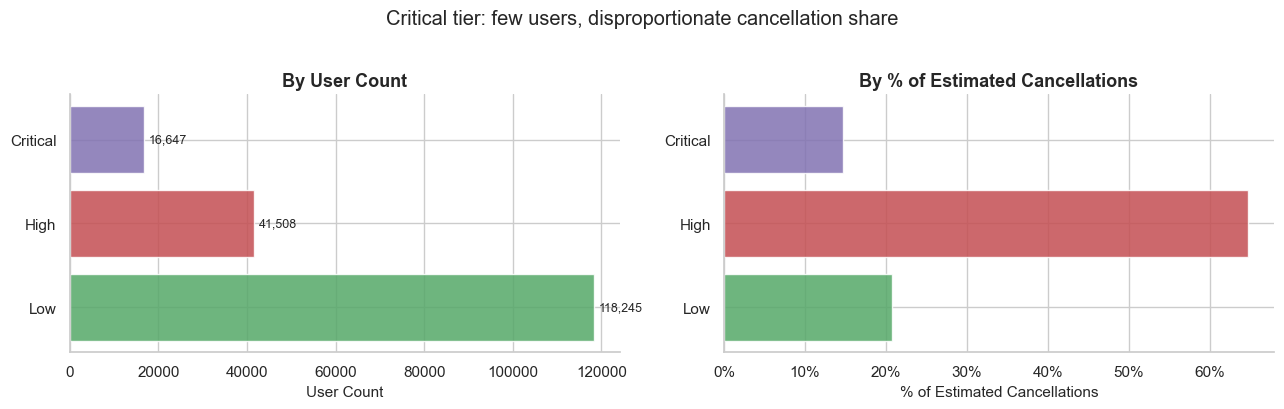

In [34]:
# ── tier summary chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (col, label) in zip(axes, [('user_count', 'User Count'),
                                    ('cancel_pct', '% of Estimated Cancellations')]):
    ordered = tier_summary.set_index('risk_tier').reindex(
        [t for t in TIER_ORDER if t in tier_summary['risk_tier'].values])
    bars = ax.barh(ordered.index, ordered[col],
                   color=[TIER_COLORS[t] for t in ordered.index], alpha=0.85)
    ax.set_xlabel(label)
    ax.set_title(f'By {label}')
    if col == 'user_count':
        for bar, v in zip(bars, ordered[col]):
            ax.text(bar.get_width() + max(ordered[col])*0.01, bar.get_y() + bar.get_height()/2,
                    f'{v:,}', va='center', fontsize=9)
    else:
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.suptitle('Critical tier: few users, disproportionate cancellation share', y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig('tier_summary.png', bbox_inches='tight', dpi=100)
plt.show()


### Recommended actions by tier

| Risk Tier | Clusters | Recommended Action | Primary Metric |
|---|---|---|---|
| **Low** | Good Users, Casual / Inactives | No action; log only | Retention |
| **High** | Serial Quick Cancelers, Fare Hunters | Show cancel-fee warning after 2nd cancel in session; cap promo eligibility for repeat cancelers | Cancel rate trend, promo redemption per cancel |
| **Critical — Baiters** | Baiters | Enforce cancel fee after driver arrives; deprioritize in driver matching queue | Post-arrival cancel rate, driver earnings per hour |
| **Critical — Colluders** | Suspected Colluders | Flag for manual ops review; freeze promo eligibility pending investigation | Escalation queue size, confirmed cases |

**Why contribution margin is enriched post-clustering, not a clustering feature:**

Contribution margin (fare revenue minus promo cost, driver incentive, ops overhead) is a financial outcome, not a behavioral signal. If we cluster on it, we'll end up with clusters that separate high-revenue from low-revenue users — which isn't the question we're asking. Instead, we add it as an enrichment attribute after clustering: a baiter with high contribution margin is still a baiter, but they might get a grace period before enforcement while a low-margin baiter gets immediate restriction.

**Production refresh strategy:**

- Weekly: recompute 90-day feature window, run `kmeans_model.predict()` on all active users in batches, update risk tiers in the policy engine.
- Quarterly: retrain the KMeans model from scratch. Cancel behavior shifts seasonally (holiday travel, monsoon months, new driver supply programs change the baseline). A model trained in Q1 may not have stable centroids by Q3.

**North star metric:**

Not cancel rate reduction. *Driver earnings per hour on platform.* A world where we've reduced cancel rate by cracking down on casual users who occasionally cancel is a world with fewer drivers and worse experience. The question is whether the drivers who encounter these users are earning more. That's the number that matters.


---
## 10. Limitations & Next Steps


### What this doesn't capture (and where it would break on real data)

**Synthesized data.** The cluster recovery check in Section 8 validates the methodology, not real-world performance. Real cancellation distributions are messier; the archetype fractions would be different; and there are behavioral patterns in real data we didn't model here. This should be treated as a proof-of-concept on the approach, not a production-ready segmentation.

**Driver-side context.** If a driver had 8 cancellations in the last two hours, the next rider who "takes too long" is probably fine. In production you'd filter out orders where the driver had recent cancels before computing user-level blame features. Otherwise you're attributing driver behavior to riders.

**Corporate accounts.** Business users booking for others, using company promo codes, getting picked up from offices — they look like fare hunters on paper. They should be excluded from this segmentation entirely.

**New users.** The 3-order floor drops them from the analysis. For users in their first 30 days, you'd need a separate lighter-weight model or just a default tier with no action until they accumulate history.

**Concept drift.** Cancel behavior shifts seasonally — monsoon months, holiday travel, driver supply changes from incentive programs. A model trained in Q1 can have stale centroids by Q3. Quarterly retraining is the minimum; the drift signal to watch is how far the cluster centroids move between training runs.

**Feature importance.** We know which features *describe* each cluster, but not which ones are *driving* membership for individual users. A follow-on supervised model trained on cluster labels (with SHAP for interpretation) would tell you where to focus feature investment.

---

### What to do next

**A/B test the cancel fee warning on High-tier users.** 50/50 split, treatment gets a friction warning on the 2nd cancel in a session. Run for 4 weeks minimum. Primary metric: driver earnings in the treatment group's sessions, not just cancel rate reduction.

**Add graph features for the colluder segment.** The `top_driver_concentration` feature is a weak proxy. The real colluder signal is in the bipartite graph structure — users who share a small driver network with other suspicious users. Even simple graph metrics (shared neighbors, clustering coefficient) would sharpen detection significantly.

**Productionize the scoring pipeline.** The model artifact + scaler is under 1MB serialized. A lightweight scoring service that takes user_id, looks up their precomputed feature vector, and returns cluster + risk_tier can serve in under 10ms. That opens real-time use cases that the nightly batch job can't support.
